# ERCOT North-West Basis Risk & DA/RT Convergence Analysis

## Project Objective

This project analyzes ERCOT HB_NORTH and HB_WEST day-ahead market (DAM) and real-time market (RTM) prices from January 1, 2024 through June 6, 2026. The goal is to evaluate two related power-market risks:

1. **DA/RT convergence risk** — whether day-ahead prices tend to clear above or below real-time prices at each hub.

2. **North-West basis risk** — how the price differential between HB_NORTH and HB_WEST behaves across DAM and RTM markets.

The analysis also links the largest DA/RT and North-West basis events to ERCOT physical system conditions, including system load, wind generation, solar generation, renewable share of load, net load, and net-load ramp.

The project is focused on market structure, spread behavior, volatility, tail-risk exposure, and physical-driver attribution. It is not framed as a guaranteed arbitrage strategy.

## Dataset

The final price dataset contains:

- 42,618 merged DAM/RTM hourly hub observations
- 21,309 North-West basis observations
- Hubs analyzed: HB_NORTH and HB_WEST
- Price-data date range: 2024-01-01 to 2026-06-06

RTM interval data was averaged into hourly prices to align with DAM hourly settlement data.

The physical-driver attribution dataset covers the clean overlap period from 2024-01-01 through 2025-12-31 and includes:

- ERCOT system load
- ERCOT wind generation
- ERCOT solar generation
- Renewable generation as a share of load
- Net load
- Net-load ramp

## Core Formulas

DA/RT Spread = DAM Price - RTM Price

North-West Basis = HB_NORTH Price - HB_WEST Price

Basis Difference = RTM North-West Basis - DAM North-West Basis

Net Load = ERCOT System Load - Wind Generation - Solar Generation

Renewable Share of Load = Renewable Generation / ERCOT System Load

## High-Level Findings

The analysis shows a modest positive DA/RT spread at both hubs, with HB_WEST showing a slightly higher average and median spread than HB_NORTH. However, DA/RT convergence exposure is dominated by low-frequency, high-severity tail events caused by RTM price spikes.

North-West basis risk is smaller in average terms, but RTM basis is materially more volatile than DAM basis, indicating that regional divergence is more severe in real-time market conditions.

The physical-driver attribution layer shows that the worst DA/RT outcomes occurred during higher net-load, lower renewable-share, and positive ramping conditions. North-West basis events showed different physical regimes, with positive RTM basis events associated with high renewable-output conditions and negative RTM basis events associated with lower renewable output and higher net load.


In [1]:
# Clean Notebook - Cell 1: Imports and load final cleaned outputs

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Locate outputs folder
if Path("../outputs").exists():
    output_folder = Path("../outputs")
elif Path("outputs").exists():
    output_folder = Path("outputs")
else:
    raise FileNotFoundError("Could not find the outputs folder. Make sure this notebook is inside the ERCOT_Basis_Project folder or a notebooks subfolder.")

# Load final datasets
market_merge = pd.read_csv(output_folder / "final_market_merge_dam_rtm_spreads.csv")
basis_df = pd.read_csv(output_folder / "final_north_west_basis.csv")
executive_summary = pd.read_csv(output_folder / "executive_summary_metrics.csv")

monthly_basis = pd.read_csv(output_folder / "monthly_north_west_basis_summary.csv")
hourly_basis = pd.read_csv(output_folder / "hourly_north_west_basis_summary.csv")
monthly_spread = pd.read_csv(output_folder / "monthly_da_rt_spread_summary.csv")
hourly_spread = pd.read_csv(output_folder / "hourly_da_rt_spread_summary.csv")

spread_tail = pd.read_csv(output_folder / "da_rt_spread_tail_risk_by_hub.csv")
rtm_basis_tail = pd.read_csv(output_folder / "rtm_north_west_basis_tail_risk.csv")
dam_basis_tail = pd.read_csv(output_folder / "dam_north_west_basis_tail_risk.csv")

# Parse dates
market_merge["Delivery Date"] = pd.to_datetime(market_merge["Delivery Date"])
basis_df["Delivery Date"] = pd.to_datetime(basis_df["Delivery Date"])

# Validate loaded data
print("=== DATA LOAD CHECK ===")
print("Market merge rows:", len(market_merge))
print("Basis rows:", len(basis_df))
print("Market date range:", market_merge["Delivery Date"].min(), "to", market_merge["Delivery Date"].max())
print("Basis date range:", basis_df["Delivery Date"].min(), "to", basis_df["Delivery Date"].max())

print("\nExecutive summary:")
display(executive_summary)

=== DATA LOAD CHECK ===
Market merge rows: 42618
Basis rows: 21309
Market date range: 2024-01-01 00:00:00 to 2026-06-06 00:00:00
Basis date range: 2024-01-01 00:00:00 to 2026-06-06 00:00:00

Executive summary:


,Metric,Observations,Mean,Median,Volatility,P01,P05,P95,P99,Worst_1pct_Avg,Best_1pct_Avg,Pct_Positive,Pct_Negative,Pct_Below_Neg_100,Pct_Below_Neg_500,Pct_Below_Neg_1000,Pct_Above_Pos_100,Pct_Above_Pos_500,Pct_Above_Pos_1000
0,HB_NORTH DA/RT Spread,21309,1.70,1.37,56.57,-70.35,-20.05,21.27,70.17,-217.92,259.38,58.45,41.55,0.61,0.07,0.05,0.70,0.12,0.04
1,HB_WEST DA/RT Spread,21309,1.92,1.77,57.71,-74.66,-22.90,23.32,75.05,-221.98,269.64,59.54,40.44,0.69,0.07,0.05,0.72,0.12,0.05
2,DAM North-West Basis,21309,-0.57,-0.87,9.55,-26.36,-12.47,16.55,26.88,-42.08,32.91,36.82,62.70,0.05,0.00,0.00,0.00,0.00,0.00
3,RTM North-West Basis,21309,-0.35,-0.04,14.19,-42.26,-17.68,20.73,37.68,-68.87,61.62,38.73,52.57,0.12,0.00,0.00,0.12,0.00,0.00


In [2]:
# Clean Notebook - Cell 2: Data validation and coverage summary

print("=== DATA VALIDATION SUMMARY ===")

# Basic shape checks
print(f"Market merge rows: {len(market_merge):,}")
print(f"Basis rows: {len(basis_df):,}")

# Date coverage
market_start = market_merge["Delivery Date"].min()
market_end = market_merge["Delivery Date"].max()
basis_start = basis_df["Delivery Date"].min()
basis_end = basis_df["Delivery Date"].max()

print(f"Market date range: {market_start.date()} to {market_end.date()}")
print(f"Basis date range: {basis_start.date()} to {basis_end.date()}")

# Hub coverage
print("\nHub counts:")
display(market_merge["Hub"].value_counts().reset_index().rename(columns={
    "Hub": "Hub",
    "count": "Rows"
}))

# Year/hub coverage
coverage_by_year_hub = (
    market_merge
    .groupby([market_merge["Delivery Date"].dt.year.rename("Year"), "Hub"])
    .agg(
        start_date=("Delivery Date", "min"),
        end_date=("Delivery Date", "max"),
        unique_dates=("Delivery Date", "nunique"),
        hourly_rows=("DA_RT_Spread", "count")
    )
    .reset_index()
)

print("\nCoverage by year and hub:")
display(coverage_by_year_hub)

# Missing value checks
missing_check = pd.DataFrame({
    "Column": market_merge.columns,
    "Missing_Values": market_merge.isna().sum().values,
    "Missing_Pct": (market_merge.isna().mean().values * 100)
}).round(2)

print("\nMissing value check:")
display(missing_check)

=== DATA VALIDATION SUMMARY ===
Market merge rows: 42,618
Basis rows: 21,309
Market date range: 2024-01-01 to 2026-06-06
Basis date range: 2024-01-01 to 2026-06-06

Hub counts:


,Hub,Rows
0,HB_NORTH,21309
1,HB_WEST,21309



Coverage by year and hub:


,Year,Hub,start_date,end_date,unique_dates,hourly_rows
0,2024,HB_NORTH,2024-01-01,2024-12-31,366,8783
1,2024,HB_WEST,2024-01-01,2024-12-31,366,8783
2,2025,HB_NORTH,2025-01-01,2025-12-31,365,8759
3,2025,HB_WEST,2025-01-01,2025-12-31,365,8759
4,2026,HB_NORTH,2026-01-01,2026-06-06,157,3767
5,2026,HB_WEST,2026-01-01,2026-06-06,157,3767



Missing value check:


,Column,Missing_Values,Missing_Pct
0,Delivery Date,0,0.0
1,Hour Ending,0,0.0
2,Hub,0,0.0
3,DAM_Price,0,0.0
4,RTM_Price,0,0.0
5,DA_RT_Spread,0,0.0


In [3]:
# Clean Notebook - Cell 3: Executive summary metrics

print("=== EXECUTIVE SUMMARY METRICS ===")

# Reorder and format executive summary for readability
summary_display = executive_summary.copy()

# Select most important columns for notebook display
summary_display = summary_display[
    [
        "Metric",
        "Observations",
        "Mean",
        "Median",
        "Volatility",
        "P01",
        "P05",
        "P95",
        "P99",
        "Worst_1pct_Avg",
        "Best_1pct_Avg",
        "Pct_Positive",
        "Pct_Negative",
        "Pct_Below_Neg_100",
        "Pct_Below_Neg_500",
        "Pct_Below_Neg_1000"
    ]
]

display(summary_display)

print("\nKey findings:")
print("1. HB_NORTH and HB_WEST both show modest positive average and median DA/RT spreads.")
print("2. HB_WEST has a slightly stronger DA/RT spread profile than HB_NORTH.")
print("3. DA/RT convergence exposure is dominated by left-tail RTM price spike risk.")
print("4. RTM North-West basis is more volatile than DAM North-West basis.")
print("5. The project should be framed as convergence and basis-risk analysis, not guaranteed arbitrage.")

=== EXECUTIVE SUMMARY METRICS ===


,Metric,Observations,Mean,Median,Volatility,P01,P05,P95,P99,Worst_1pct_Avg,Best_1pct_Avg,Pct_Positive,Pct_Negative,Pct_Below_Neg_100,Pct_Below_Neg_500,Pct_Below_Neg_1000
0,HB_NORTH DA/RT Spread,21309,1.70,1.37,56.57,-70.35,-20.05,21.27,70.17,-217.92,259.38,58.45,41.55,0.61,0.07,0.05
1,HB_WEST DA/RT Spread,21309,1.92,1.77,57.71,-74.66,-22.90,23.32,75.05,-221.98,269.64,59.54,40.44,0.69,0.07,0.05
2,DAM North-West Basis,21309,-0.57,-0.87,9.55,-26.36,-12.47,16.55,26.88,-42.08,32.91,36.82,62.70,0.05,0.00,0.00
3,RTM North-West Basis,21309,-0.35,-0.04,14.19,-42.26,-17.68,20.73,37.68,-68.87,61.62,38.73,52.57,0.12,0.00,0.00



Key findings:
1. HB_NORTH and HB_WEST both show modest positive average and median DA/RT spreads.
2. HB_WEST has a slightly stronger DA/RT spread profile than HB_NORTH.
3. DA/RT convergence exposure is dominated by left-tail RTM price spike risk.
4. RTM North-West basis is more volatile than DAM North-West basis.
5. The project should be framed as convergence and basis-risk analysis, not guaranteed arbitrage.


=== MONTHLY DA/RT SPREAD TREND BY HUB ===


,Year,Month,Hub,avg_da_rt_spread,spread_median,spread_vol,min_spread,max_spread,positive_spread_pct,observations
0,2024,1,HB_NORTH,11.20,0.44,106.02,-350.45,1599.13,52.96,744
1,2024,1,HB_WEST,13.42,3.18,107.03,-341.37,1611.54,65.05,744
2,2024,2,HB_NORTH,0.44,2.07,10.74,-89.27,30.47,63.65,696
3,2024,2,HB_WEST,-0.34,1.92,12.73,-89.09,32.70,62.64,696
4,2024,3,HB_NORTH,1.26,1.93,27.69,-583.60,221.68,60.03,743
5,2024,3,HB_WEST,1.09,4.23,33.27,-566.31,192.63,69.45,743
6,2024,4,HB_NORTH,-1.81,1.83,48.71,-696.06,225.89,59.58,720
7,2024,4,HB_WEST,-0.20,2.47,47.48,-661.39,212.88,65.14,720
8,2024,5,HB_NORTH,7.67,1.23,94.82,-1144.03,1423.69,57.26,744
9,2024,5,HB_WEST,8.20,2.40,94.28,-1122.68,1423.40,60.62,744


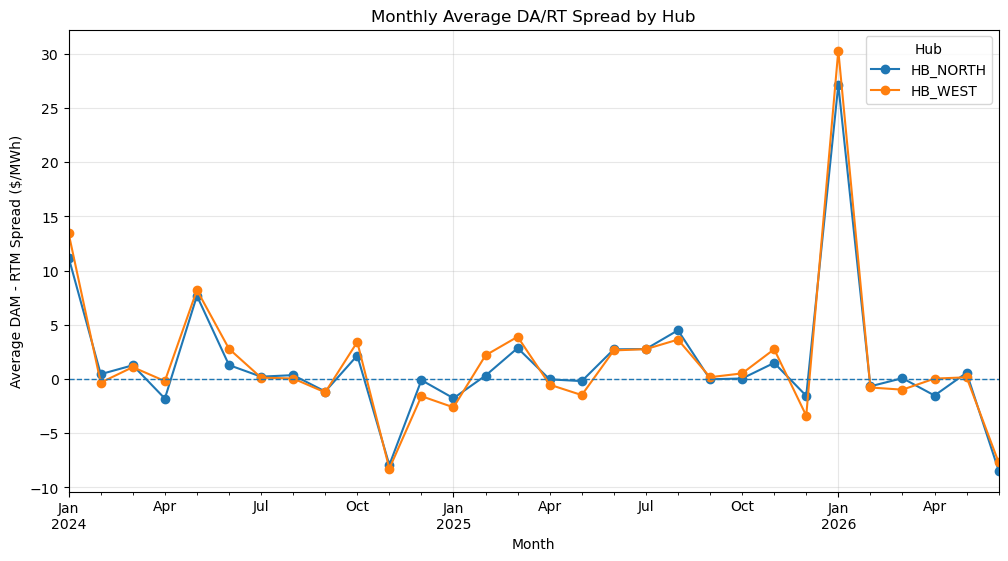

Interpretation:
Monthly DA/RT spreads are modestly positive on average, but individual months show major volatility due to RTM price spikes and scarcity events.


In [4]:
# Clean Notebook - Cell 4: Monthly DA/RT spread trend by hub

print("=== MONTHLY DA/RT SPREAD TREND BY HUB ===")

monthly_spread_clean = monthly_spread.copy()

# Create date column for plotting
monthly_spread_clean["Month_Date"] = pd.to_datetime(
    monthly_spread_clean["Year"].astype(str) + "-" +
    monthly_spread_clean["Month"].astype(str) + "-01"
)

# Display monthly table
display(monthly_spread_clean[
    [
        "Year",
        "Month",
        "Hub",
        "avg_da_rt_spread",
        "spread_median",
        "spread_vol",
        "min_spread",
        "max_spread",
        "positive_spread_pct",
        "observations"
    ]
])

# Pivot for chart
monthly_spread_pivot = monthly_spread_clean.pivot(
    index="Month_Date",
    columns="Hub",
    values="avg_da_rt_spread"
)

# Plot monthly average DA/RT spread
plt.figure(figsize=(12, 6))
monthly_spread_pivot.plot(ax=plt.gca(), marker="o")

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Monthly Average DA/RT Spread by Hub")
plt.xlabel("Month")
plt.ylabel("Average DAM - RTM Spread ($/MWh)")
plt.legend(title="Hub")
plt.grid(True, alpha=0.3)
plt.show()

print("Interpretation:")
print("Monthly DA/RT spreads are modestly positive on average, but individual months show major volatility due to RTM price spikes and scarcity events.")

=== HOURLY DA/RT SPREAD PATTERN BY HUB ===


,Hour Ending,Hub,avg_da_rt_spread,spread_median,spread_vol,min_spread,max_spread,positive_spread_pct,observations
0,1,HB_NORTH,1.20,0.66,32.26,-165.66,835.91,56.08,888
1,1,HB_WEST,0.88,1.12,33.05,-164.84,828.22,55.97,888
2,2,HB_NORTH,0.48,0.33,24.26,-188.27,548.90,52.59,888
3,2,HB_WEST,0.30,0.86,25.41,-185.72,540.72,53.04,888
4,3,HB_NORTH,0.58,0.02,31.03,-263.21,759.20,50.06,885
5,3,HB_WEST,0.55,0.61,32.64,-261.96,766.72,53.33,885
6,4,HB_NORTH,0.84,0.21,33.46,-211.61,826.85,51.24,888
7,4,HB_WEST,0.81,1.03,35.52,-251.78,848.13,55.07,888
8,5,HB_NORTH,1.20,0.43,37.48,-207.41,940.61,54.28,888
9,5,HB_WEST,1.14,0.94,39.92,-189.01,989.30,55.52,888


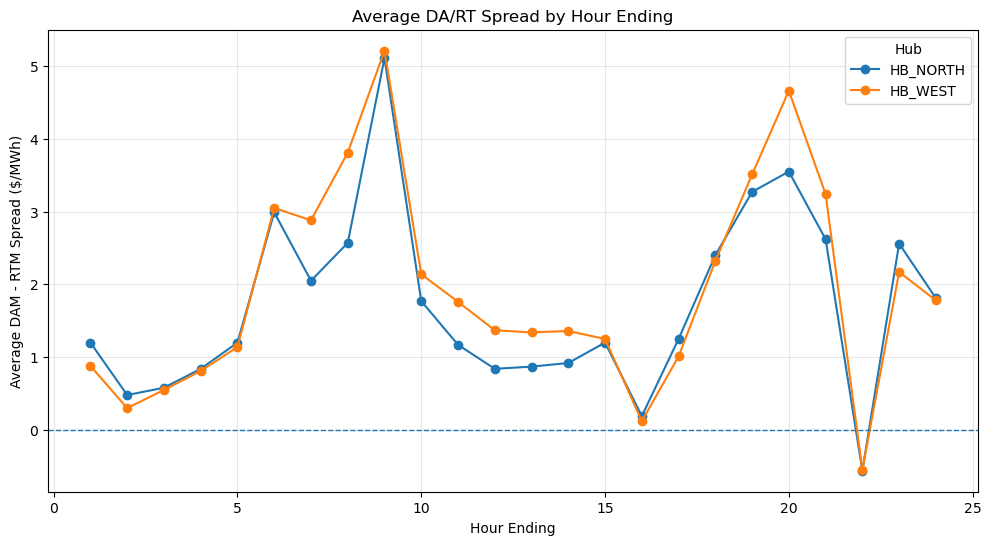

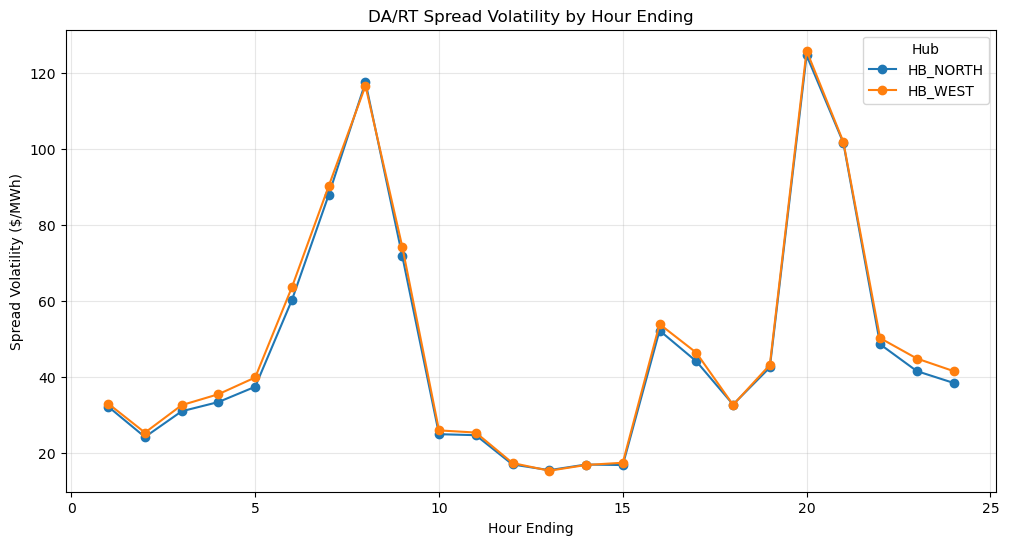

Interpretation:
The DA/RT spread is not evenly distributed across the day. Positive median spreads are strongest in evening hours, but volatility and downside exposure also increase during high-stress real-time periods.


In [5]:
# Clean Notebook - Cell 5: Hourly DA/RT spread pattern by hub

print("=== HOURLY DA/RT SPREAD PATTERN BY HUB ===")

hourly_spread_clean = hourly_spread.copy()

# Display hourly table
display(hourly_spread_clean[
    [
        "Hour Ending",
        "Hub",
        "avg_da_rt_spread",
        "spread_median",
        "spread_vol",
        "min_spread",
        "max_spread",
        "positive_spread_pct",
        "observations"
    ]
])

# Pivot average spread for chart
hourly_avg_pivot = hourly_spread_clean.pivot(
    index="Hour Ending",
    columns="Hub",
    values="avg_da_rt_spread"
)

plt.figure(figsize=(12, 6))
hourly_avg_pivot.plot(ax=plt.gca(), marker="o")

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Average DA/RT Spread by Hour Ending")
plt.xlabel("Hour Ending")
plt.ylabel("Average DAM - RTM Spread ($/MWh)")
plt.legend(title="Hub")
plt.grid(True, alpha=0.3)
plt.show()

# Pivot volatility for chart
hourly_vol_pivot = hourly_spread_clean.pivot(
    index="Hour Ending",
    columns="Hub",
    values="spread_vol"
)

plt.figure(figsize=(12, 6))
hourly_vol_pivot.plot(ax=plt.gca(), marker="o")

plt.title("DA/RT Spread Volatility by Hour Ending")
plt.xlabel("Hour Ending")
plt.ylabel("Spread Volatility ($/MWh)")
plt.legend(title="Hub")
plt.grid(True, alpha=0.3)
plt.show()

print("Interpretation:")
print("The DA/RT spread is not evenly distributed across the day. Positive median spreads are strongest in evening hours, but volatility and downside exposure also increase during high-stress real-time periods.")

=== MONTHLY NORTH-WEST BASIS ANALYSIS ===


,Year,Month,avg_dam_basis,avg_rtm_basis,dam_basis_vol,rtm_basis_vol,max_rtm_basis,min_rtm_basis,observations
0,2024,1,-3.05,-0.83,7.33,12.31,53.32,-151.00,744
1,2024,2,-0.90,-1.69,4.74,9.65,48.99,-67.15,696
2,2024,3,-9.50,-9.67,15.39,25.39,35.95,-260.33,743
3,2024,4,-1.01,0.60,9.84,14.65,67.26,-111.52,720
4,2024,5,-0.22,0.31,5.70,10.46,84.38,-56.63,744
5,2024,6,0.75,2.25,6.05,12.30,129.76,-75.02,720
6,2024,7,-0.57,-0.66,5.59,10.02,114.69,-29.66,744
7,2024,8,-2.75,-3.07,4.24,7.00,39.16,-41.86,744
8,2024,9,-3.27,-3.35,5.93,12.54,80.04,-173.04,720
9,2024,10,-0.62,0.62,13.29,19.06,141.94,-154.99,744


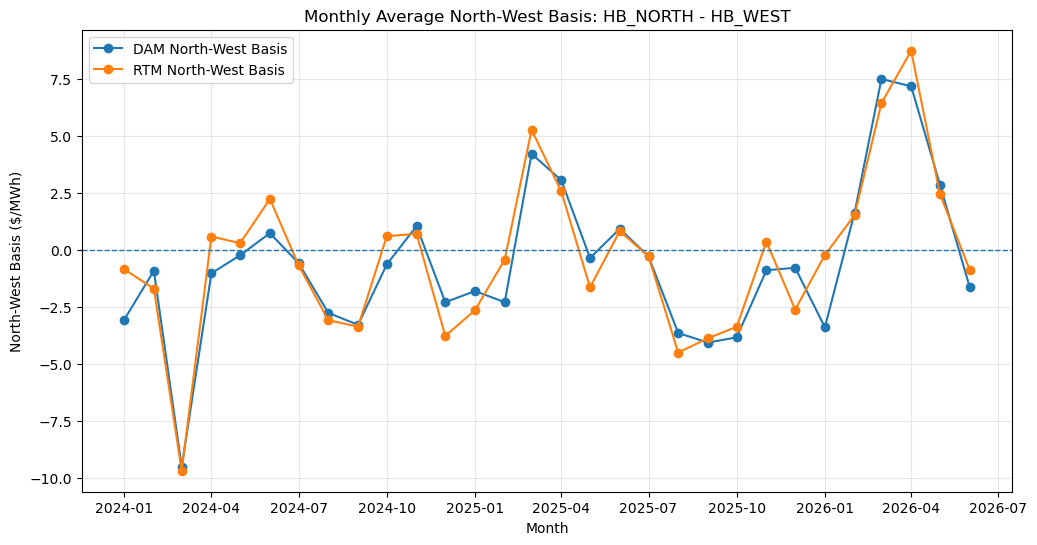

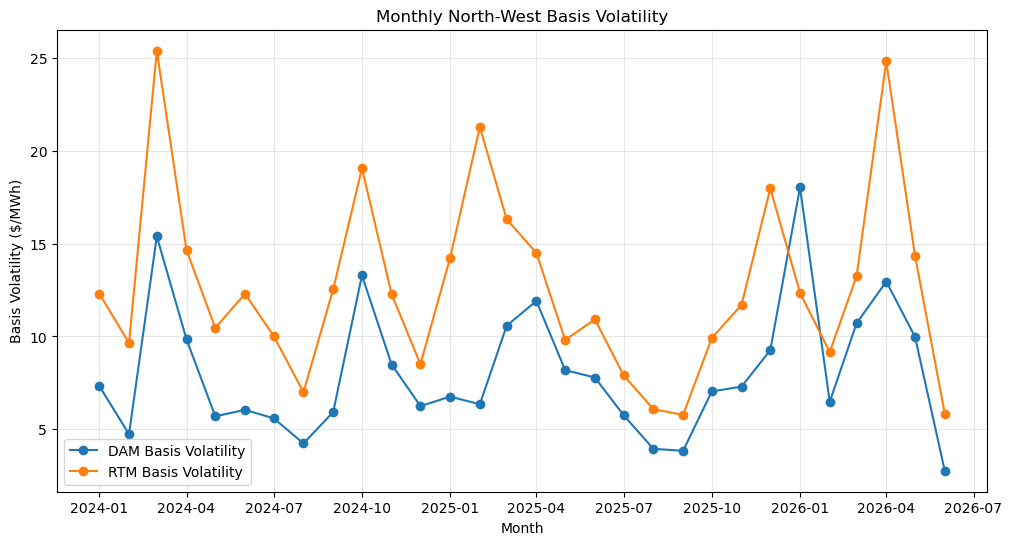

Interpretation:
North-West average basis is modest over the full sample, but RTM basis is consistently more volatile than DAM basis. This suggests that regional price divergence is more severe in real-time market conditions.


In [6]:
# Clean Notebook - Cell 6: Monthly North-West basis analysis

print("=== MONTHLY NORTH-WEST BASIS ANALYSIS ===")

monthly_basis_clean = monthly_basis.copy()

# Create date column for plotting
monthly_basis_clean["Month_Date"] = pd.to_datetime(
    monthly_basis_clean["Year"].astype(str) + "-" +
    monthly_basis_clean["Month"].astype(str) + "-01"
)

# Display monthly basis table
display(monthly_basis_clean[
    [
        "Year",
        "Month",
        "avg_dam_basis",
        "avg_rtm_basis",
        "dam_basis_vol",
        "rtm_basis_vol",
        "max_rtm_basis",
        "min_rtm_basis",
        "observations"
    ]
])

# Plot monthly average DAM and RTM North-West basis
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_basis_clean["Month_Date"],
    monthly_basis_clean["avg_dam_basis"],
    marker="o",
    label="DAM North-West Basis"
)

plt.plot(
    monthly_basis_clean["Month_Date"],
    monthly_basis_clean["avg_rtm_basis"],
    marker="o",
    label="RTM North-West Basis"
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Monthly Average North-West Basis: HB_NORTH - HB_WEST")
plt.xlabel("Month")
plt.ylabel("North-West Basis ($/MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot monthly basis volatility
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_basis_clean["Month_Date"],
    monthly_basis_clean["dam_basis_vol"],
    marker="o",
    label="DAM Basis Volatility"
)

plt.plot(
    monthly_basis_clean["Month_Date"],
    monthly_basis_clean["rtm_basis_vol"],
    marker="o",
    label="RTM Basis Volatility"
)

plt.title("Monthly North-West Basis Volatility")
plt.xlabel("Month")
plt.ylabel("Basis Volatility ($/MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Interpretation:")
print("North-West average basis is modest over the full sample, but RTM basis is consistently more volatile than DAM basis. This suggests that regional price divergence is more severe in real-time market conditions.")

=== HOURLY NORTH-WEST BASIS PATTERN ===


,Hour Ending,avg_dam_basis,avg_rtm_basis,dam_basis_vol,rtm_basis_vol,max_rtm_basis,min_rtm_basis,observations
0,1,-2.35,-2.67,9.12,12.85,40.32,-101.58,888
1,2,-2.43,-2.60,8.61,12.18,34.92,-99.24,888
2,3,-2.62,-2.65,8.14,11.89,35.33,-116.65,885
3,4,-2.86,-2.88,8.39,12.54,35.28,-134.29,888
4,5,-3.15,-3.21,8.53,11.93,46.54,-85.49,888
5,6,-3.10,-3.04,8.86,13.14,110.72,-109.24,888
6,7,-2.90,-2.07,10.08,16.01,187.29,-137.04,888
7,8,-2.31,-1.07,9.92,15.67,194.88,-121.62,888
8,9,0.59,0.69,8.17,11.08,186.64,-104.81,888
9,10,2.23,2.59,6.72,11.73,196.01,-157.44,888


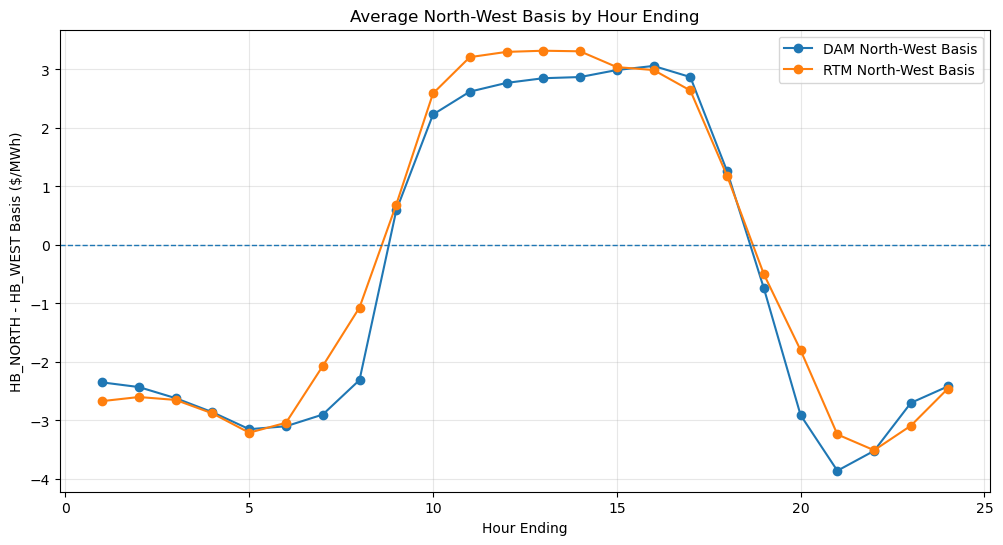

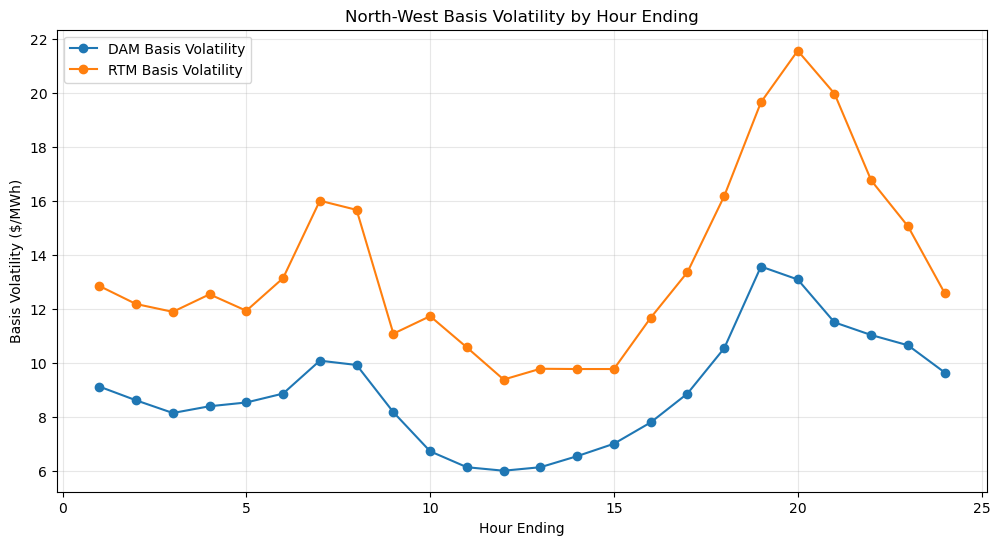

Interpretation:
North-West basis shows a clear intraday pattern. North tends to trade above West during mid-day hours, while West tends to outperform North overnight and in late evening hours. RTM basis volatility is highest during stressed real-time operating hours.


In [7]:
# Clean Notebook - Cell 7: Hourly North-West basis pattern

print("=== HOURLY NORTH-WEST BASIS PATTERN ===")

hourly_basis_clean = hourly_basis.copy()

# Display hourly basis table
display(hourly_basis_clean[
    [
        "Hour Ending",
        "avg_dam_basis",
        "avg_rtm_basis",
        "dam_basis_vol",
        "rtm_basis_vol",
        "max_rtm_basis",
        "min_rtm_basis",
        "observations"
    ]
])

# Plot hourly average DAM and RTM basis
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_basis_clean["Hour Ending"],
    hourly_basis_clean["avg_dam_basis"],
    marker="o",
    label="DAM North-West Basis"
)

plt.plot(
    hourly_basis_clean["Hour Ending"],
    hourly_basis_clean["avg_rtm_basis"],
    marker="o",
    label="RTM North-West Basis"
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Average North-West Basis by Hour Ending")
plt.xlabel("Hour Ending")
plt.ylabel("HB_NORTH - HB_WEST Basis ($/MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot hourly basis volatility
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_basis_clean["Hour Ending"],
    hourly_basis_clean["dam_basis_vol"],
    marker="o",
    label="DAM Basis Volatility"
)

plt.plot(
    hourly_basis_clean["Hour Ending"],
    hourly_basis_clean["rtm_basis_vol"],
    marker="o",
    label="RTM Basis Volatility"
)

plt.title("North-West Basis Volatility by Hour Ending")
plt.xlabel("Hour Ending")
plt.ylabel("Basis Volatility ($/MWh)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Interpretation:")
print("North-West basis shows a clear intraday pattern. North tends to trade above West during mid-day hours, while West tends to outperform North overnight and in late evening hours. RTM basis volatility is highest during stressed real-time operating hours.")

=== TAIL-RISK DIAGNOSTICS ===

DA/RT spread tail risk by hub:


,Hub,observations,mean,median,std,p01,p05,p95,p99,worst_1pct_avg,best_1pct_avg,pct_positive,pct_negative,pct_below_neg_100,pct_below_neg_500,pct_below_neg_1000,pct_above_pos_100,pct_above_pos_500,pct_above_pos_1000
0,HB_NORTH,21309,1.70,1.37,56.57,-70.35,-20.05,21.27,70.17,-217.92,259.38,58.45,41.55,0.61,0.07,0.05,0.70,0.12,0.04
1,HB_WEST,21309,1.92,1.77,57.71,-74.66,-22.90,23.32,75.05,-221.98,269.64,59.54,40.44,0.69,0.07,0.05,0.72,0.12,0.05



RTM North-West basis tail risk:


,Group,observations,mean,median,std,p01,p05,p95,p99,worst_1pct_avg,best_1pct_avg,pct_positive,pct_negative,pct_below_neg_100,pct_below_neg_500,pct_below_neg_1000,pct_above_pos_100,pct_above_pos_500,pct_above_pos_1000
0,North-West RTM Basis,21309,-0.35,-0.04,14.19,-42.26,-17.68,20.73,37.68,-68.87,61.62,38.73,52.57,0.12,0.0,0.0,0.12,0.0,0.0



DAM North-West basis tail risk:


,Group,observations,mean,median,std,p01,p05,p95,p99,worst_1pct_avg,best_1pct_avg,pct_positive,pct_negative,pct_below_neg_100,pct_below_neg_500,pct_below_neg_1000,pct_above_pos_100,pct_above_pos_500,pct_above_pos_1000
0,North-West DAM Basis,21309,-0.57,-0.87,9.55,-26.36,-12.47,16.55,26.88,-42.08,32.91,36.82,62.7,0.05,0.0,0.0,0.0,0.0,0.0


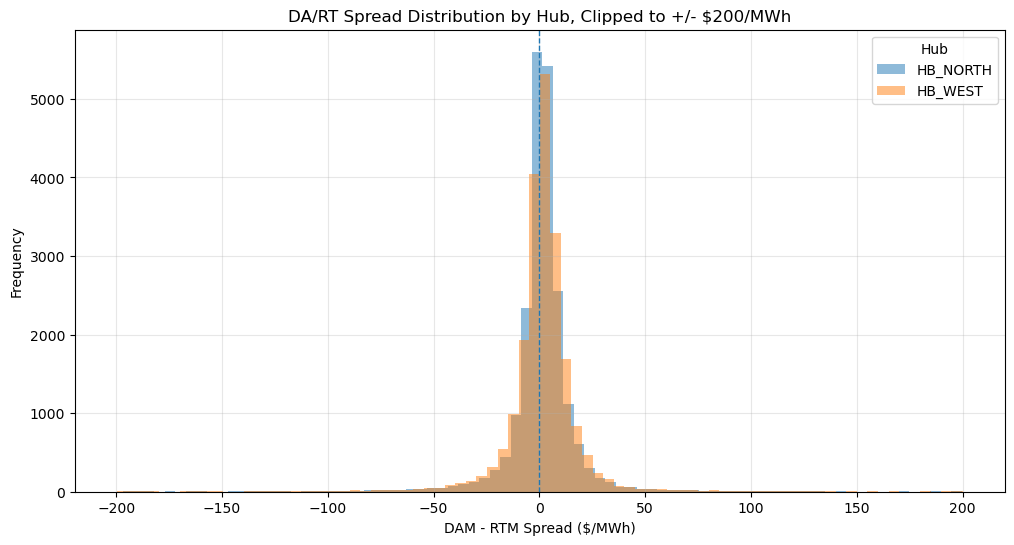

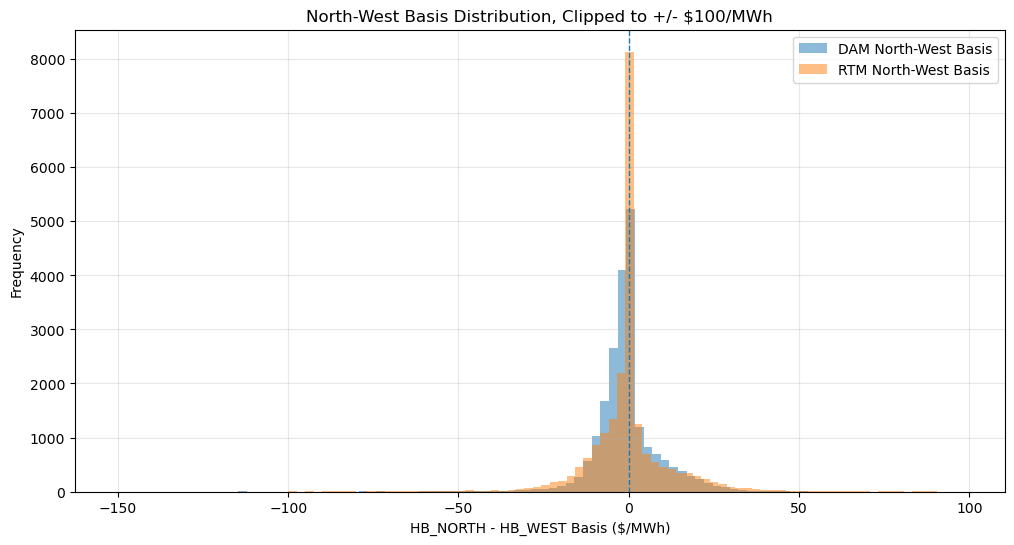

Interpretation:
DA/RT spreads have modest positive central tendency, but the distribution contains severe downside events when RTM prices spike above DAM. North-West basis risk is less extreme than DA/RT convergence risk, but RTM basis has wider tails than DAM basis.


In [8]:
# Clean Notebook - Cell 8: Tail-risk diagnostics

print("=== TAIL-RISK DIAGNOSTICS ===")

print("\nDA/RT spread tail risk by hub:")
display(spread_tail)

print("\nRTM North-West basis tail risk:")
display(rtm_basis_tail)

print("\nDAM North-West basis tail risk:")
display(dam_basis_tail)

# Plot DA/RT spread distribution, clipped to make the main distribution readable
spread_plot = market_merge.copy()
spread_plot_clipped = spread_plot[
    (spread_plot["DA_RT_Spread"] >= -200) &
    (spread_plot["DA_RT_Spread"] <= 200)
]

plt.figure(figsize=(12, 6))

for hub in spread_plot_clipped["Hub"].unique():
    temp = spread_plot_clipped[spread_plot_clipped["Hub"] == hub]
    plt.hist(
        temp["DA_RT_Spread"],
        bins=80,
        alpha=0.5,
        label=hub
    )

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("DA/RT Spread Distribution by Hub, Clipped to +/- $200/MWh")
plt.xlabel("DAM - RTM Spread ($/MWh)")
plt.ylabel("Frequency")
plt.legend(title="Hub")
plt.grid(True, alpha=0.3)
plt.show()

# Plot North-West basis distribution, clipped for readability
basis_plot_clipped = basis_df[
    (basis_df["RTM_North_West_Basis"] >= -100) &
    (basis_df["RTM_North_West_Basis"] <= 100)
]

plt.figure(figsize=(12, 6))

plt.hist(
    basis_plot_clipped["DAM_North_West_Basis"],
    bins=80,
    alpha=0.5,
    label="DAM North-West Basis"
)

plt.hist(
    basis_plot_clipped["RTM_North_West_Basis"],
    bins=80,
    alpha=0.5,
    label="RTM North-West Basis"
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("North-West Basis Distribution, Clipped to +/- $100/MWh")
plt.xlabel("HB_NORTH - HB_WEST Basis ($/MWh)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Interpretation:")
print("DA/RT spreads have modest positive central tendency, but the distribution contains severe downside events when RTM prices spike above DAM. North-West basis risk is less extreme than DA/RT convergence risk, but RTM basis has wider tails than DAM basis.")

In [9]:
# Clean Notebook - Cell 9: Largest tail events

print("=== LARGEST DA/RT AND BASIS TAIL EVENTS ===")

# Largest positive DA/RT spreads
top_positive_spread = (
    market_merge
    .sort_values("DA_RT_Spread", ascending=False)
    .head(10)
    [[
        "Delivery Date",
        "Hour Ending",
        "Hub",
        "DAM_Price",
        "RTM_Price",
        "DA_RT_Spread"
    ]]
)

print("\nTop 10 positive DA/RT spread events:")
display(top_positive_spread)

# Largest negative DA/RT spreads
top_negative_spread = (
    market_merge
    .sort_values("DA_RT_Spread", ascending=True)
    .head(10)
    [[
        "Delivery Date",
        "Hour Ending",
        "Hub",
        "DAM_Price",
        "RTM_Price",
        "DA_RT_Spread"
    ]]
)

print("\nTop 10 negative DA/RT spread events:")
display(top_negative_spread)

# Largest positive RTM North-West basis events
top_positive_basis = (
    basis_df
    .sort_values("RTM_North_West_Basis", ascending=False)
    .head(10)
    [[
        "Delivery Date",
        "Hour Ending",
        "DAM_North_West_Basis",
        "RTM_North_West_Basis",
        "Basis_Difference_RTM_minus_DAM"
    ]]
)

print("\nTop 10 positive RTM North-West basis events:")
display(top_positive_basis)

# Largest negative RTM North-West basis events
top_negative_basis = (
    basis_df
    .sort_values("RTM_North_West_Basis", ascending=True)
    .head(10)
    [[
        "Delivery Date",
        "Hour Ending",
        "DAM_North_West_Basis",
        "RTM_North_West_Basis",
        "Basis_Difference_RTM_minus_DAM"
    ]]
)

print("\nTop 10 negative RTM North-West basis events:")
display(top_negative_basis)

print("Interpretation:")
print("The largest DA/RT losses occur when RTM clears far above DAM, creating severe convergence risk. The largest North-West basis events show that regional hub divergence can widen materially during stressed real-time conditions.")

=== LARGEST DA/RT AND BASIS TAIL EVENTS ===

Top 10 positive DA/RT spread events:


,Delivery Date,Hour Ending,Hub,DAM_Price,RTM_Price,DA_RT_Spread
36299,2026-01-26,8,HB_WEST,1911.52,203.1400,1708.3800
36295,2026-01-26,6,HB_WEST,2000.17,355.6100,1644.5600
735,2024-01-16,8,HB_WEST,2039.85,428.3150,1611.5350
734,2024-01-16,8,HB_NORTH,1994.65,395.5175,1599.1325
36298,2026-01-26,8,HB_NORTH,1773.12,180.9425,1592.1775
36294,2026-01-26,6,HB_NORTH,1899.19,334.8475,1564.3425
36301,2026-01-26,9,HB_WEST,1672.13,147.2375,1524.8925
36297,2026-01-26,7,HB_WEST,1806.23,292.8100,1513.4200
7046,2024-05-26,21,HB_NORTH,1522.07,98.3800,1423.6900
7047,2024-05-26,21,HB_WEST,1539.79,116.3875,1423.4025



Top 10 negative DA/RT spread events:


,Delivery Date,Hour Ending,Hub,DAM_Price,RTM_Price,DA_RT_Spread
11172,2024-08-20,20,HB_NORTH,648.03,3048.1625,-2400.1325
11173,2024-08-20,20,HB_WEST,666.58,3038.3350,-2371.7550
18252,2025-01-15,8,HB_NORTH,59.98,2087.0275,-2027.0475
18253,2025-01-15,8,HB_WEST,77.56,1963.4075,-1885.8475
15437,2024-11-17,16,HB_WEST,69.14,1597.1150,-1527.9750
24083,2025-05-16,20,HB_WEST,209.24,1734.4025,-1525.1625
15436,2024-11-17,16,HB_NORTH,66.52,1551.3725,-1484.8525
24082,2025-05-16,20,HB_NORTH,196.53,1673.4375,-1476.9075
22184,2025-04-07,7,HB_NORTH,98.37,1551.8875,-1453.5175
22185,2025-04-07,7,HB_WEST,108.21,1540.6825,-1432.4725



Top 10 positive RTM North-West basis events:


,Delivery Date,Hour Ending,DAM_North_West_Basis,RTM_North_West_Basis,Basis_Difference_RTM_minus_DAM
9968,2025-02-19,10,9.12,196.0050,186.8850
9966,2025-02-19,8,15.62,194.8825,179.2625
9965,2025-02-19,7,12.83,187.2900,174.4600
9967,2025-02-19,9,13.22,186.6375,173.4175
20009,2026-04-13,21,46.37,170.5775,124.2075
9969,2025-02-19,11,6.51,165.1900,158.6800
19913,2026-04-09,21,14.32,161.1850,146.8650
20008,2026-04-13,20,47.67,153.9075,106.2375
19914,2026-04-09,22,18.87,151.4675,132.5975
6928,2024-10-15,18,-11.58,141.9425,153.5225



Top 10 negative RTM North-West basis events:


,Delivery Date,Hour Ending,DAM_North_West_Basis,RTM_North_West_Basis,Basis_Difference_RTM_minus_DAM
1604,2024-03-07,21,-31.44,-260.3300,-228.8900
1603,2024-03-07,20,-29.81,-208.9150,-179.1050
6546,2024-09-29,20,-48.83,-173.0375,-124.2075
20275,2026-04-24,23,-12.82,-168.8900,-156.0700
1808,2024-03-16,10,-27.58,-157.4400,-129.8600
7097,2024-10-22,19,-55.40,-154.9900,-99.5900
617,2024-01-26,18,-1.70,-150.9975,-149.2975
20451,2026-05-02,7,-18.53,-137.0425,-118.5125
17137,2025-12-15,4,-15.98,-134.2900,-118.3100
736,2024-01-31,17,-3.08,-134.2300,-131.1500


Interpretation:
The largest DA/RT losses occur when RTM clears far above DAM, creating severe convergence risk. The largest North-West basis events show that regional hub divergence can widen materially during stressed real-time conditions.


In [10]:
#Clean Notebook - Cell 10: Physical-driver dataset: load, wind, solar, net load, and net-load ramp

from pathlib import Path
import pandas as pd
import numpy as np
import zipfile

print("=== LOAD PHYSICAL DRIVER DATA ===")

project_root = Path("..")
driver_folder = project_root / "data_physical_drivers"
load_folder = driver_folder / "load"
wind_solar_folder = driver_folder / "wind_solar"

# -----------------------------
# 1. Load ERCOT actual system load
# -----------------------------

load_file = load_folder / "actual_system_load_weather_zone_2024_2026.zip"

with zipfile.ZipFile(load_file, "r") as z:
    inner_csv = z.namelist()[0]
    with z.open(inner_csv) as f:
        load_raw = pd.read_csv(f)

load = load_raw.copy()

load["Delivery Date"] = pd.to_datetime(load["operatingDay"], errors="coerce")

load["Hour Ending"] = (
    load["hourEnding"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

load["ERCOT_Load_MW"] = pd.to_numeric(load["total"], errors="coerce")

load_hourly = (
    load
    .dropna(subset=["Delivery Date", "Hour Ending", "ERCOT_Load_MW"])
    .groupby(["Delivery Date", "Hour Ending"], as_index=False)
    .agg(
        ERCOT_Load_MW=("ERCOT_Load_MW", "mean")
    )
)

load_hourly["Hour Ending"] = load_hourly["Hour Ending"].astype(int)

print("Load rows:", len(load_hourly))
print("Load date range:", load_hourly["Delivery Date"].min(), "to", load_hourly["Delivery Date"].max())


# -----------------------------
# 2. Load annual wind/solar files
# -----------------------------

def read_excel_sheet_fast(file_path, sheet_name):
    try:
        return pd.read_excel(file_path, sheet_name=sheet_name, engine="calamine")
    except Exception:
        return pd.read_excel(file_path, sheet_name=sheet_name)


def read_wind_solar_file(file_path):
    wind = read_excel_sheet_fast(file_path, "Wind Data")
    solar = read_excel_sheet_fast(file_path, "Solar Data")
    
    wind.columns = wind.columns.str.strip()
    solar.columns = solar.columns.str.strip()
    
    # Known columns from ERCOT files
    wind_time_col = "Time (Hour-Ending)"
    solar_time_col = "Time (Hour-Ending)"
    date_col = "Date"
    wind_gen_col = "ERCOT.WIND.GEN"
    solar_gen_col = "ERCOT.PVGR.GEN"
    
    required_wind_cols = [wind_time_col, date_col, wind_gen_col]
    required_solar_cols = [solar_time_col, date_col, solar_gen_col]
    
    missing_wind = [col for col in required_wind_cols if col not in wind.columns]
    missing_solar = [col for col in required_solar_cols if col not in solar.columns]
    
    if missing_wind:
        raise ValueError(f"Missing wind columns in {file_path.name}: {missing_wind}")
    if missing_solar:
        raise ValueError(f"Missing solar columns in {file_path.name}: {missing_solar}")
    
    wind_clean = wind[required_wind_cols].copy()
    solar_clean = solar[required_solar_cols].copy()
    
    wind_clean = wind_clean.rename(columns={
        wind_time_col: "Time_Hour_Ending",
        date_col: "Delivery Date",
        wind_gen_col: "Wind_Gen_MW"
    })
    
    solar_clean = solar_clean.rename(columns={
        solar_time_col: "Time_Hour_Ending",
        date_col: "Delivery Date",
        solar_gen_col: "Solar_Gen_MW"
    })
    
    wind_clean["Delivery Date"] = pd.to_datetime(wind_clean["Delivery Date"], errors="coerce")
    solar_clean["Delivery Date"] = pd.to_datetime(solar_clean["Delivery Date"], errors="coerce")
    
    wind_clean["Time_Hour_Ending"] = pd.to_datetime(wind_clean["Time_Hour_Ending"], errors="coerce")
    solar_clean["Time_Hour_Ending"] = pd.to_datetime(solar_clean["Time_Hour_Ending"], errors="coerce")
    
    wind_clean["Hour Ending"] = wind_clean["Time_Hour_Ending"].dt.hour
    solar_clean["Hour Ending"] = solar_clean["Time_Hour_Ending"].dt.hour
    
    # Convert midnight timestamp to Hour Ending 24
    wind_clean.loc[wind_clean["Hour Ending"] == 0, "Hour Ending"] = 24
    solar_clean.loc[solar_clean["Hour Ending"] == 0, "Hour Ending"] = 24
    
    wind_clean["Wind_Gen_MW"] = pd.to_numeric(wind_clean["Wind_Gen_MW"], errors="coerce")
    solar_clean["Solar_Gen_MW"] = pd.to_numeric(solar_clean["Solar_Gen_MW"], errors="coerce")
    
    merged = pd.merge(
        wind_clean[["Delivery Date", "Hour Ending", "Wind_Gen_MW"]],
        solar_clean[["Delivery Date", "Hour Ending", "Solar_Gen_MW"]],
        on=["Delivery Date", "Hour Ending"],
        how="inner"
    )
    
    merged["Source_File"] = file_path.name
    
    return merged


wind_solar_files = [
    wind_solar_folder / "ERCOT_2024_Hourly_WindSolar_Output.xlsx",
    wind_solar_folder / "ERCOT_2025_Hourly_WindSolar_Output.xlsx"
]

wind_solar_hourly = pd.concat(
    [read_wind_solar_file(file) for file in wind_solar_files],
    ignore_index=True
)

wind_solar_hourly = (
    wind_solar_hourly
    .dropna(subset=["Delivery Date", "Hour Ending", "Wind_Gen_MW", "Solar_Gen_MW"])
    .groupby(["Delivery Date", "Hour Ending"], as_index=False)
    .agg(
        Wind_Gen_MW=("Wind_Gen_MW", "mean"),
        Solar_Gen_MW=("Solar_Gen_MW", "mean")
    )
)

wind_solar_hourly["Hour Ending"] = wind_solar_hourly["Hour Ending"].astype(int)

print("Wind/solar rows:", len(wind_solar_hourly))
print("Wind/solar date range:", wind_solar_hourly["Delivery Date"].min(), "to", wind_solar_hourly["Delivery Date"].max())


# -----------------------------
# 3. Merge load, wind, solar and calculate net load
# -----------------------------

physical_drivers = pd.merge(
    load_hourly,
    wind_solar_hourly,
    on=["Delivery Date", "Hour Ending"],
    how="inner"
)

physical_drivers = physical_drivers.sort_values(["Delivery Date", "Hour Ending"]).reset_index(drop=True)

physical_drivers["Net_Load_MW"] = (
    physical_drivers["ERCOT_Load_MW"]
    - physical_drivers["Wind_Gen_MW"]
    - physical_drivers["Solar_Gen_MW"]
)

physical_drivers["Net_Load_Ramp_MW"] = physical_drivers["Net_Load_MW"].diff()

physical_drivers["Previous_Date"] = physical_drivers["Delivery Date"].shift(1)

physical_drivers.loc[
    (physical_drivers["Delivery Date"] - physical_drivers["Previous_Date"]).dt.days > 1,
    "Net_Load_Ramp_MW"
] = np.nan

physical_drivers = physical_drivers.drop(columns=["Previous_Date"])

print("\nPre-filter physical driver rows:", len(physical_drivers))
print("Pre-filter physical driver date range:", physical_drivers["Delivery Date"].min(), "to", physical_drivers["Delivery Date"].max())

display(physical_drivers.head())
display(physical_drivers.tail())

=== LOAD PHYSICAL DRIVER DATA ===
Load rows: 22317
Load date range: 2023-12-11 00:00:00 to 2026-06-28 00:00:00
Wind/solar rows: 17542
Wind/solar date range: 2024-01-01 00:00:00 to 2026-01-01 00:00:00

Pre-filter physical driver rows: 17516
Pre-filter physical driver date range: 2024-01-01 00:00:00 to 2026-01-01 00:00:00


,Delivery Date,Hour Ending,ERCOT_Load_MW,Wind_Gen_MW,Solar_Gen_MW,Net_Load_MW,Net_Load_Ramp_MW
0,2024-01-01,1,41367.30,14826.134442,0.038771,26541.126786,NaN
1,2024-01-01,2,41630.87,13892.784408,0.035091,27738.050501,1196.923715
2,2024-01-01,3,41563.17,12973.109221,0.025540,28590.035239,851.984737
3,2024-01-01,4,41539.61,11974.790659,0.029920,29564.789421,974.754182
4,2024-01-01,5,42199.84,10799.054299,0.043062,31400.742639,1835.953218


,Delivery Date,Hour Ending,ERCOT_Load_MW,Wind_Gen_MW,Solar_Gen_MW,Net_Load_MW,Net_Load_Ramp_MW
17511,2025-12-31,21,49013.71,13073.831037,0.261824,35939.617139,-3886.385945
17512,2025-12-31,22,48254.52,15597.708151,0.252944,32656.558905,-3283.058234
17513,2025-12-31,23,47395.40,17978.649136,0.274709,29416.476155,-3240.082751
17514,2025-12-31,24,46812.28,12031.177114,0.333358,34780.769529,5364.293374
17515,2026-01-01,24,44223.96,19803.969184,0.267612,24419.723204,-10361.046325


In [11]:
#Clean Notebook - Cell 11: Physical Driver Data Validation and Coverage Summary
print("=== VALIDATE PHYSICAL DRIVER DATASET ===")

# Keep only the clean overlap period with annual wind/solar data
physical_drivers_clean = physical_drivers[
    (physical_drivers["Delivery Date"] >= "2024-01-01") &
    (physical_drivers["Delivery Date"] <= "2025-12-31")
].copy()

physical_drivers_clean = physical_drivers_clean.sort_values(
    ["Delivery Date", "Hour Ending"]
).reset_index(drop=True)

# Recalculate net-load ramp after filtering
physical_drivers_clean["Net_Load_Ramp_MW"] = physical_drivers_clean["Net_Load_MW"].diff()

# Set first row ramp to NaN
physical_drivers_clean.loc[0, "Net_Load_Ramp_MW"] = np.nan

print("Rows:", len(physical_drivers_clean))
print("Date range:", physical_drivers_clean["Delivery Date"].min(), "to", physical_drivers_clean["Delivery Date"].max())

print("\nMissing values:")
missing_physical = pd.DataFrame({
    "Column": physical_drivers_clean.columns,
    "Missing_Values": physical_drivers_clean.isna().sum().values,
    "Missing_Pct": (physical_drivers_clean.isna().mean().values * 100)
}).round(2)

display(missing_physical)

print("\nRows by year:")
physical_rows_by_year = (
    physical_drivers_clean
    .groupby(physical_drivers_clean["Delivery Date"].dt.year.rename("Year"))
    .size()
    .reset_index(name="Rows")
)

display(physical_rows_by_year)

print("\nPhysical-driver summary statistics:")
physical_summary = physical_drivers_clean[
    [
        "ERCOT_Load_MW",
        "Wind_Gen_MW",
        "Solar_Gen_MW",
        "Net_Load_MW",
        "Net_Load_Ramp_MW"
    ]
].describe().round(2)

display(physical_summary)

print("\nPreview:")
display(physical_drivers_clean.head())
display(physical_drivers_clean.tail())

=== VALIDATE PHYSICAL DRIVER DATASET ===
Rows: 17515
Date range: 2024-01-01 00:00:00 to 2025-12-31 00:00:00

Missing values:


,Column,Missing_Values,Missing_Pct
0,Delivery Date,0,0.00
1,Hour Ending,0,0.00
2,ERCOT_Load_MW,0,0.00
3,Wind_Gen_MW,0,0.00
4,Solar_Gen_MW,0,0.00
5,Net_Load_MW,0,0.00
6,Net_Load_Ramp_MW,1,0.01



Rows by year:


,Year,Rows
0,2024,8781
1,2025,8734



Physical-driver summary statistics:


,ERCOT_Load_MW,Wind_Gen_MW,Solar_Gen_MW,Net_Load_MW,Net_Load_Ramp_MW
count,17515.00,17515.00,17515.00,17515.00,17514.00
mean,54662.09,12920.44,6578.85,35162.80,0.47
std,10458.24,6863.12,8345.49,11262.76,3520.37
min,36193.16,168.65,0.00,11106.06,-24573.86
25%,46850.16,6988.69,0.53,26489.05,-1493.81
50%,52243.44,12535.36,413.01,35033.47,107.84
75%,61129.58,18704.74,13472.12,43087.49,1661.94
max,85558.98,28264.50,29503.09,69974.87,22813.52



Preview:


,Delivery Date,Hour Ending,ERCOT_Load_MW,Wind_Gen_MW,Solar_Gen_MW,Net_Load_MW,Net_Load_Ramp_MW
0,2024-01-01,1,41367.30,14826.134442,0.038771,26541.126786,NaN
1,2024-01-01,2,41630.87,13892.784408,0.035091,27738.050501,1196.923715
2,2024-01-01,3,41563.17,12973.109221,0.025540,28590.035239,851.984737
3,2024-01-01,4,41539.61,11974.790659,0.029920,29564.789421,974.754182
4,2024-01-01,5,42199.84,10799.054299,0.043062,31400.742639,1835.953218


,Delivery Date,Hour Ending,ERCOT_Load_MW,Wind_Gen_MW,Solar_Gen_MW,Net_Load_MW,Net_Load_Ramp_MW
17510,2025-12-31,20,49805.51,9979.253995,0.252921,39826.003084,-3736.440382
17511,2025-12-31,21,49013.71,13073.831037,0.261824,35939.617139,-3886.385945
17512,2025-12-31,22,48254.52,15597.708151,0.252944,32656.558905,-3283.058234
17513,2025-12-31,23,47395.40,17978.649136,0.274709,29416.476155,-3240.082751
17514,2025-12-31,24,46812.28,12031.177114,0.333358,34780.769529,5364.293374


In [12]:
#Clean Notebook - Cell 12: Merge physical drivers with DA/RT spreads and North-West basis

print("=== MERGE PHYSICAL DRIVERS WITH PRICE/SPREAD DATA ===")

# Restrict market data to clean physical-driver period
market_overlap = market_merge[
    (market_merge["Delivery Date"] >= "2024-01-01") &
    (market_merge["Delivery Date"] <= "2025-12-31")
].copy()

basis_overlap = basis_df[
    (basis_df["Delivery Date"] >= "2024-01-01") &
    (basis_df["Delivery Date"] <= "2025-12-31")
].copy()

# Merge physical drivers onto hub-level DA/RT spread data
driver_market = pd.merge(
    market_overlap,
    physical_drivers_clean,
    on=["Delivery Date", "Hour Ending"],
    how="inner"
)

# Merge North-West basis onto the same dataset
driver_market = pd.merge(
    driver_market,
    basis_overlap[
        [
            "Delivery Date",
            "Hour Ending",
            "DAM_North_West_Basis",
            "RTM_North_West_Basis",
            "Basis_Difference_RTM_minus_DAM"
        ]
    ],
    on=["Delivery Date", "Hour Ending"],
    how="inner"
)

# Add useful time fields
driver_market["Year"] = driver_market["Delivery Date"].dt.year
driver_market["Month"] = driver_market["Delivery Date"].dt.month
driver_market["Day"] = driver_market["Delivery Date"].dt.day
driver_market["Day_of_Week"] = driver_market["Delivery Date"].dt.day_name()

# Add renewable share and net-load percentile
driver_market["Renewable_Gen_MW"] = driver_market["Wind_Gen_MW"] + driver_market["Solar_Gen_MW"]

driver_market["Renewable_Share_of_Load"] = (
    driver_market["Renewable_Gen_MW"] / driver_market["ERCOT_Load_MW"]
)

driver_market["Net_Load_Percentile"] = driver_market["Net_Load_MW"].rank(pct=True) * 100
driver_market["Net_Load_Ramp_Percentile"] = driver_market["Net_Load_Ramp_MW"].rank(pct=True) * 100

print("Driver-market rows:", len(driver_market))
print("Date range:", driver_market["Delivery Date"].min(), "to", driver_market["Delivery Date"].max())

print("\nRows by hub:")
display(driver_market["Hub"].value_counts().reset_index().rename(columns={
    "Hub": "Hub",
    "count": "Rows"
}))

print("\nRows by year and hub:")
display(
    driver_market
    .groupby(["Year", "Hub"])
    .size()
    .reset_index(name="Rows")
)

print("\nMissing value check:")
missing_driver_market = pd.DataFrame({
    "Column": driver_market.columns,
    "Missing_Values": driver_market.isna().sum().values,
    "Missing_Pct": (driver_market.isna().mean().values * 100)
}).round(2)

display(missing_driver_market)

print("\nPreview:")
display(driver_market.head())

=== MERGE PHYSICAL DRIVERS WITH PRICE/SPREAD DATA ===
Driver-market rows: 35030
Date range: 2024-01-01 00:00:00 to 2025-12-31 00:00:00

Rows by hub:


,Hub,Rows
0,HB_NORTH,17515
1,HB_WEST,17515



Rows by year and hub:


,Year,Hub,Rows
0,2024,HB_NORTH,8781
1,2024,HB_WEST,8781
2,2025,HB_NORTH,8734
3,2025,HB_WEST,8734



Missing value check:


,Column,Missing_Values,Missing_Pct
0,Delivery Date,0,0.00
1,Hour Ending,0,0.00
2,Hub,0,0.00
3,DAM_Price,0,0.00
4,RTM_Price,0,0.00
5,DA_RT_Spread,0,0.00
6,ERCOT_Load_MW,0,0.00
7,Wind_Gen_MW,0,0.00
8,Solar_Gen_MW,0,0.00
9,Net_Load_MW,0,0.00



Preview:


,Delivery Date,Hour Ending,Hub,DAM_Price,RTM_Price,DA_RT_Spread,ERCOT_Load_MW,Wind_Gen_MW,Solar_Gen_MW,Net_Load_MW,...,RTM_North_West_Basis,Basis_Difference_RTM_minus_DAM,Year,Month,Day,Day_of_Week,Renewable_Gen_MW,Renewable_Share_of_Load,Net_Load_Percentile,Net_Load_Ramp_Percentile
0,2024-01-01,1,HB_NORTH,16.31,14.8700,1.4400,41367.30,14826.134442,0.038771,26541.126786,...,-0.6225,2.8575,2024,1,1,Monday,14826.173214,0.358403,25.102769,NaN
1,2024-01-01,1,HB_WEST,19.79,15.4925,4.2975,41367.30,14826.134442,0.038771,26541.126786,...,-0.6225,2.8575,2024,1,1,Monday,14826.173214,0.358403,25.102769,NaN
2,2024-01-01,2,HB_NORTH,17.05,16.0900,0.9600,41630.87,13892.784408,0.035091,27738.050501,...,-0.6150,3.2350,2024,1,1,Monday,13892.819499,0.333714,28.482729,68.703609
3,2024-01-01,2,HB_WEST,20.90,16.7050,4.1950,41630.87,13892.784408,0.035091,27738.050501,...,-0.6150,3.2350,2024,1,1,Monday,13892.819499,0.333714,28.482729,68.703609
4,2024-01-01,3,HB_NORTH,16.79,16.9950,-0.2050,41563.17,12973.109221,0.025540,28590.035239,...,0.0000,4.5500,2024,1,1,Monday,12973.134761,0.312131,30.583785,63.404990


In [13]:
#Clean Notebook - Cell 13: Physical Driver Attribution of DA/RT Tail Risk and North-West Basis Events

print("=== PHYSICAL DRIVER ATTRIBUTION OF TAIL EVENTS ===")

driver_cols = [
    "ERCOT_Load_MW",
    "Wind_Gen_MW",
    "Solar_Gen_MW",
    "Renewable_Gen_MW",
    "Renewable_Share_of_Load",
    "Net_Load_MW",
    "Net_Load_Ramp_MW"
]

# Summarize physical conditions during full-sample, worst-tail, and best-tail DA/RT outcomes
tail_rows = []

for hub in sorted(driver_market["Hub"].unique()):
    hub_data = driver_market[driver_market["Hub"] == hub].copy()
    
    downside_threshold = hub_data["DA_RT_Spread"].quantile(0.01)
    upside_threshold = hub_data["DA_RT_Spread"].quantile(0.99)
    
    downside_tail = hub_data[hub_data["DA_RT_Spread"] <= downside_threshold].copy()
    upside_tail = hub_data[hub_data["DA_RT_Spread"] >= upside_threshold].copy()
    
    full_summary = hub_data[driver_cols + ["DA_RT_Spread"]].mean()
    downside_summary = downside_tail[driver_cols + ["DA_RT_Spread"]].mean()
    upside_summary = upside_tail[driver_cols + ["DA_RT_Spread"]].mean()
    
    for condition_name, temp_summary, obs_count, threshold in [
        ("Full Sample", full_summary, len(hub_data), np.nan),
        ("Worst 1% DA/RT Outcomes", downside_summary, len(downside_tail), downside_threshold),
        ("Best 1% DA/RT Outcomes", upside_summary, len(upside_tail), upside_threshold)
    ]:
        tail_rows.append({
            "Hub": hub,
            "Condition": condition_name,
            "Observations": obs_count,
            "DA_RT_Threshold": threshold,
            "Avg_DA_RT_Spread": temp_summary["DA_RT_Spread"],
            "Avg_Load_MW": temp_summary["ERCOT_Load_MW"],
            "Avg_Wind_MW": temp_summary["Wind_Gen_MW"],
            "Avg_Solar_MW": temp_summary["Solar_Gen_MW"],
            "Avg_Renewable_MW": temp_summary["Renewable_Gen_MW"],
            "Avg_Renewable_Share": temp_summary["Renewable_Share_of_Load"],
            "Avg_Net_Load_MW": temp_summary["Net_Load_MW"],
            "Avg_Net_Load_Ramp_MW": temp_summary["Net_Load_Ramp_MW"]
        })

da_rt_driver_attribution = pd.DataFrame(tail_rows).round(2)

print("\nDA/RT physical-driver attribution by hub:")
display(da_rt_driver_attribution)


# Summarize physical conditions during extreme North-West RTM basis events
basis_driver = (
    driver_market
    .drop_duplicates(subset=["Delivery Date", "Hour Ending"])
    .copy()
)

positive_basis_threshold = basis_driver["RTM_North_West_Basis"].quantile(0.99)
negative_basis_threshold = basis_driver["RTM_North_West_Basis"].quantile(0.01)
absolute_basis_threshold = basis_driver["RTM_North_West_Basis"].abs().quantile(0.99)

basis_conditions = {
    "Full Sample": basis_driver,
    "Top 1% Positive RTM Basis": basis_driver[basis_driver["RTM_North_West_Basis"] >= positive_basis_threshold],
    "Top 1% Negative RTM Basis": basis_driver[basis_driver["RTM_North_West_Basis"] <= negative_basis_threshold],
    "Top 1% Absolute RTM Basis": basis_driver[basis_driver["RTM_North_West_Basis"].abs() >= absolute_basis_threshold]
}

basis_tail_rows = []

for condition_name, temp in basis_conditions.items():
    basis_tail_rows.append({
        "Condition": condition_name,
        "Observations": len(temp),
        "Avg_RTM_North_West_Basis": temp["RTM_North_West_Basis"].mean(),
        "Avg_DAM_North_West_Basis": temp["DAM_North_West_Basis"].mean(),
        "Avg_Load_MW": temp["ERCOT_Load_MW"].mean(),
        "Avg_Wind_MW": temp["Wind_Gen_MW"].mean(),
        "Avg_Solar_MW": temp["Solar_Gen_MW"].mean(),
        "Avg_Renewable_MW": temp["Renewable_Gen_MW"].mean(),
        "Avg_Renewable_Share": temp["Renewable_Share_of_Load"].mean(),
        "Avg_Net_Load_MW": temp["Net_Load_MW"].mean(),
        "Avg_Net_Load_Ramp_MW": temp["Net_Load_Ramp_MW"].mean()
    })

basis_driver_attribution = pd.DataFrame(basis_tail_rows).round(2)

print("\nNorth-West basis physical-driver attribution:")
display(basis_driver_attribution)


# Display the largest realized DA/RT losses with physical-driver context
worst_da_rt_events = (
    driver_market
    .sort_values("DA_RT_Spread", ascending=True)
    .head(20)
    [[
        "Delivery Date",
        "Hour Ending",
        "Hub",
        "DAM_Price",
        "RTM_Price",
        "DA_RT_Spread",
        "ERCOT_Load_MW",
        "Wind_Gen_MW",
        "Solar_Gen_MW",
        "Renewable_Share_of_Load",
        "Net_Load_MW",
        "Net_Load_Ramp_MW"
    ]]
    .round(2)
)

print("\nWorst 20 DA/RT spread events with physical-driver context:")
display(worst_da_rt_events)


# Display the largest absolute RTM North-West basis events with physical-driver context
top_abs_basis_events = (
    basis_driver
    .assign(Abs_RTM_Basis=basis_driver["RTM_North_West_Basis"].abs())
    .sort_values("Abs_RTM_Basis", ascending=False)
    .head(20)
    [[
        "Delivery Date",
        "Hour Ending",
        "DAM_North_West_Basis",
        "RTM_North_West_Basis",
        "Basis_Difference_RTM_minus_DAM",
        "ERCOT_Load_MW",
        "Wind_Gen_MW",
        "Solar_Gen_MW",
        "Renewable_Share_of_Load",
        "Net_Load_MW",
        "Net_Load_Ramp_MW"
    ]]
    .round(2)
)

print("\nLargest 20 absolute RTM North-West basis events with physical-driver context:")
display(top_abs_basis_events)

=== PHYSICAL DRIVER ATTRIBUTION OF TAIL EVENTS ===

DA/RT physical-driver attribution by hub:


,Hub,Condition,Observations,DA_RT_Threshold,Avg_DA_RT_Spread,Avg_Load_MW,Avg_Wind_MW,Avg_Solar_MW,Avg_Renewable_MW,Avg_Renewable_Share,Avg_Net_Load_MW,Avg_Net_Load_Ramp_MW
0,HB_NORTH,Full Sample,17515,NaN,1.04,54662.09,12920.44,6578.85,19499.29,0.36,35162.80,0.47
1,HB_NORTH,Worst 1% DA/RT Outcomes,176,-68.55,-214.49,59135.95,8562.21,2485.37,11047.58,0.18,48088.37,1445.00
2,HB_NORTH,Best 1% DA/RT Outcomes,176,62.29,189.81,68650.71,10221.85,3864.13,14085.98,0.20,54564.73,1885.61
3,HB_WEST,Full Sample,17515,NaN,1.17,54662.09,12920.44,6578.85,19499.29,0.36,35162.80,0.47
4,HB_WEST,Worst 1% DA/RT Outcomes,176,-73.56,-222.07,56779.20,7406.12,2005.12,9411.24,0.16,47367.97,1381.49
5,HB_WEST,Best 1% DA/RT Outcomes,176,66.68,193.44,68670.95,10506.91,3686.06,14192.97,0.21,54477.98,1793.89



North-West basis physical-driver attribution:


,Condition,Observations,Avg_RTM_North_West_Basis,Avg_DAM_North_West_Basis,Avg_Load_MW,Avg_Wind_MW,Avg_Solar_MW,Avg_Renewable_MW,Avg_Renewable_Share,Avg_Net_Load_MW,Avg_Net_Load_Ramp_MW
0,Full Sample,17515,-1.19,-1.32,54662.09,12920.44,6578.85,19499.29,0.36,35162.80,0.47
1,Top 1% Positive RTM Basis,176,54.76,18.12,59382.49,21669.82,6692.21,28362.03,0.49,31020.46,1111.26
2,Top 1% Negative RTM Basis,176,-71.21,-26.22,49425.85,8739.93,918.10,9658.04,0.20,39767.81,363.29
3,Top 1% Absolute RTM Basis,176,-31.22,-13.99,54257.02,11931.90,2151.75,14083.65,0.25,40173.37,1055.19



Worst 20 DA/RT spread events with physical-driver context:


,Delivery Date,Hour Ending,Hub,DAM_Price,RTM_Price,DA_RT_Spread,ERCOT_Load_MW,Wind_Gen_MW,Solar_Gen_MW,Renewable_Share_of_Load,Net_Load_MW,Net_Load_Ramp_MW
11168,2024-08-20,20,HB_NORTH,648.03,3048.16,-2400.13,81518.80,7327.42,4216.51,0.14,69974.87,5667.84
11169,2024-08-20,20,HB_WEST,666.58,3038.34,-2371.76,81518.80,7327.42,4216.51,0.14,69974.87,5667.84
18248,2025-01-15,8,HB_NORTH,59.98,2087.03,-2027.05,57131.07,5247.87,108.45,0.09,51774.74,1268.59
18249,2025-01-15,8,HB_WEST,77.56,1963.41,-1885.85,57131.07,5247.87,108.45,0.09,51774.74,1268.59
15433,2024-11-17,16,HB_WEST,69.14,1597.12,-1527.98,51381.18,8475.11,3423.72,0.23,39482.34,2329.48
24077,2025-05-16,20,HB_WEST,209.24,1734.40,-1525.16,66933.64,4823.16,3083.68,0.12,59026.80,3434.63
15432,2024-11-17,16,HB_NORTH,66.52,1551.37,-1484.85,51381.18,8475.11,3423.72,0.23,39482.34,2329.48
24076,2025-05-16,20,HB_NORTH,196.53,1673.44,-1476.91,66933.64,4823.16,3083.68,0.12,59026.80,3434.63
22178,2025-04-07,7,HB_NORTH,98.37,1551.89,-1453.52,48037.89,4727.75,0.54,0.10,43309.60,2209.22
22179,2025-04-07,7,HB_WEST,108.21,1540.68,-1432.47,48037.89,4727.75,0.54,0.10,43309.60,2209.22



Largest 20 absolute RTM North-West basis events with physical-driver context:


,Delivery Date,Hour Ending,DAM_North_West_Basis,RTM_North_West_Basis,Basis_Difference_RTM_minus_DAM,ERCOT_Load_MW,Wind_Gen_MW,Solar_Gen_MW,Renewable_Share_of_Load,Net_Load_MW,Net_Load_Ramp_MW
3206,2024-03-07,21,-31.44,-260.33,-228.89,47022.80,10020.69,0.50,0.21,37001.62,-118.95
3204,2024-03-07,20,-29.81,-208.92,-179.10,47932.80,10811.55,0.68,0.23,37120.57,256.26
19932,2025-02-19,10,9.12,196.00,186.88,76581.23,18265.21,5619.10,0.31,52696.92,-1900.71
19928,2025-02-19,8,15.62,194.88,179.26,74290.70,19021.71,214.31,0.26,55054.68,3561.31
19926,2025-02-19,7,12.83,187.29,174.46,71793.33,20299.54,0.42,0.28,51493.37,4921.66
19930,2025-02-19,9,13.22,186.64,173.42,75374.52,18385.68,2391.21,0.28,54597.63,-457.05
13088,2024-09-29,20,-48.83,-173.04,-124.21,62329.59,1947.80,299.74,0.04,60082.04,3200.38
19934,2025-02-19,11,6.51,165.19,158.68,78084.30,17511.78,8250.96,0.33,52321.56,-375.36
3612,2024-03-16,10,-27.58,-157.44,-129.86,41104.32,4354.67,1184.60,0.13,35565.05,2024.63
14190,2024-10-22,19,-55.40,-154.99,-99.59,60455.32,3891.20,2443.88,0.10,54120.24,5698.59


## Physical Driver Attribution Findings

The physical-driver attribution layer links the largest DA/RT and North-West basis events to underlying ERCOT system conditions.

For DA/RT convergence risk, the worst 1% of outcomes occurred during higher-stress system conditions than the full sample. At HB_NORTH, the worst 1% of DA/RT outcomes had average net load of 48,088 MW versus 35,163 MW for the full sample. Renewable share fell from 36% in the full sample to 18% during the worst 1% of outcomes. HB_WEST showed a similar pattern, with average net load rising to 47,368 MW and renewable share falling to 16% during the worst 1% of DA/RT outcomes.

This suggests that severe DA/RT losses were associated with high net-load conditions, weaker renewable output, and positive net-load ramps. The DA/RT spread is therefore not only a statistical convergence problem. It is also tied to real-time physical system stress.

The North-West basis attribution shows a different physical-driver pattern. The top 1% positive RTM North-West basis events occurred during high renewable-output conditions, with average wind generation of 21,670 MW and renewable share of 49%. This is consistent with the idea that strong renewable output, particularly wind-heavy conditions, can contribute to regional price divergence between HB_NORTH and HB_WEST.

The top 1% negative RTM North-West basis events occurred during lower renewable-output conditions, with average renewable share of 20% and higher average net load than the full sample. This indicates that basis risk can widen under multiple physical regimes, not only during high-renewable periods.

Overall, the physical-driver analysis strengthens the project’s main conclusion: ERCOT DA/RT convergence and North-West basis exposure should be evaluated through a risk-adjusted framework that accounts for net load, renewable output, ramping conditions, and real-time system stress.

=== PHYSICAL DRIVER ATTRIBUTION VISUALS ===

DA/RT attribution summary for visualization:


,Hub,Condition,Avg_DA_RT_Spread,Avg_Load_MW,Avg_Renewable_Share,Avg_Net_Load_MW,Avg_Net_Load_Ramp_MW
0,HB_NORTH,Full Sample,1.04,54662.09,0.36,35162.80,0.47
1,HB_NORTH,Worst 1% DA/RT Outcomes,-214.49,59135.95,0.18,48088.37,1445.00
2,HB_NORTH,Best 1% DA/RT Outcomes,189.81,68650.71,0.20,54564.73,1885.61
3,HB_WEST,Full Sample,1.17,54662.09,0.36,35162.80,0.47
4,HB_WEST,Worst 1% DA/RT Outcomes,-222.07,56779.20,0.16,47367.97,1381.49
5,HB_WEST,Best 1% DA/RT Outcomes,193.44,68670.95,0.21,54477.98,1793.89


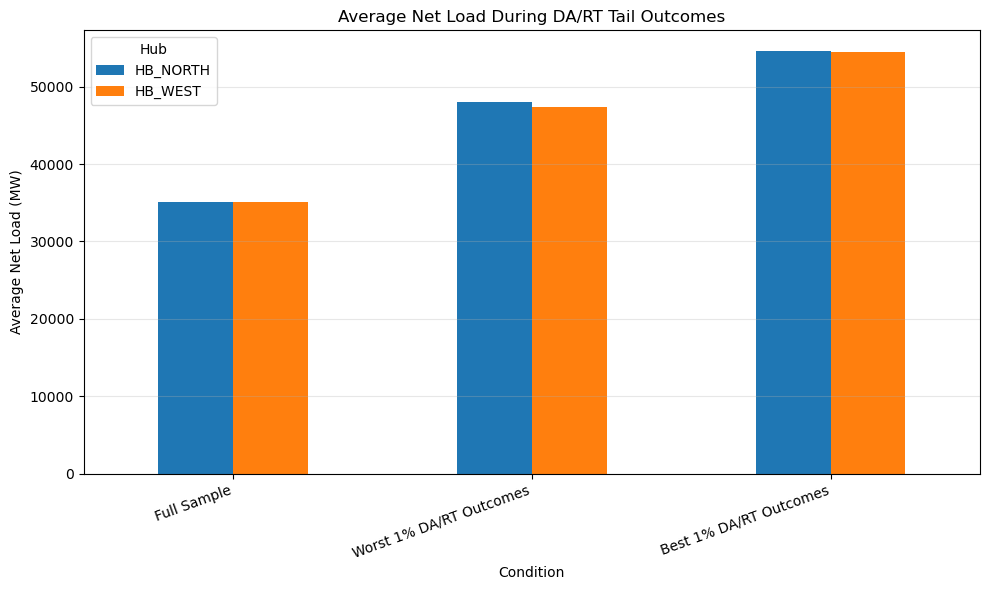

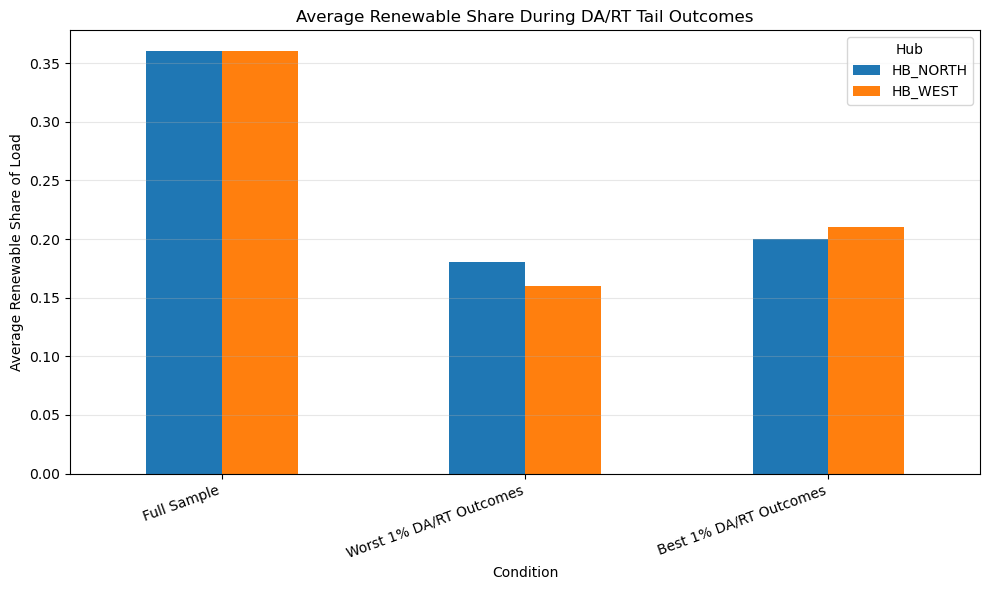


North-West basis attribution summary for visualization:


,Condition,Avg_RTM_North_West_Basis,Avg_Load_MW,Avg_Wind_MW,Avg_Renewable_Share,Avg_Net_Load_MW,Avg_Net_Load_Ramp_MW
0,Full Sample,-1.19,54662.09,12920.44,0.36,35162.80,0.47
1,Top 1% Positive RTM Basis,54.76,59382.49,21669.82,0.49,31020.46,1111.26
2,Top 1% Negative RTM Basis,-71.21,49425.85,8739.93,0.20,39767.81,363.29
3,Top 1% Absolute RTM Basis,-31.22,54257.02,11931.90,0.25,40173.37,1055.19


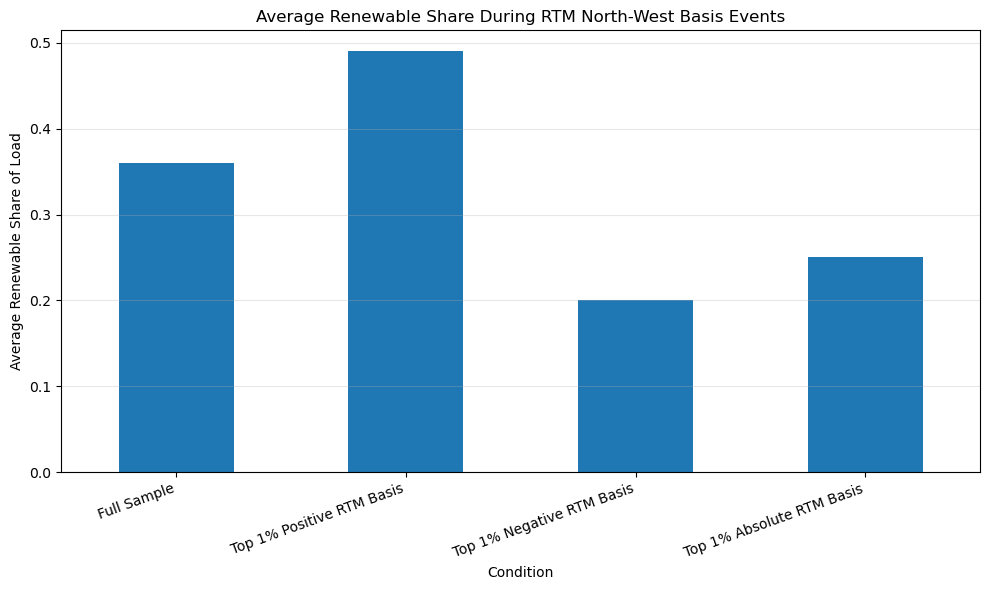

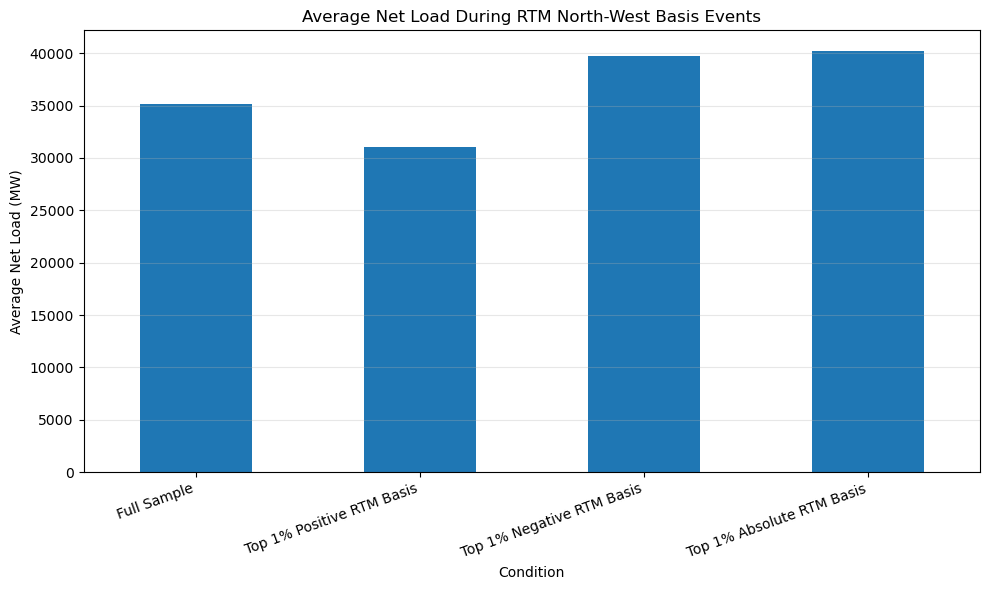

Interpretation:
The worst DA/RT outcomes occurred during materially higher net-load and lower renewable-share conditions than the full sample.
RTM North-West basis events showed different physical regimes: positive basis events were associated with higher renewable share, while negative basis events were associated with lower renewable share and higher net load.


In [14]:
#Clean Notebook - Cell 14: Physical Driver Attribution Visuals

import matplotlib.pyplot as plt

print("=== PHYSICAL DRIVER ATTRIBUTION VISUALS ===")

# --------------------------------------------------
# 1. DA/RT tail-risk driver comparison
# --------------------------------------------------

da_rt_plot_data = da_rt_driver_attribution[
    da_rt_driver_attribution["Condition"].isin([
        "Full Sample",
        "Worst 1% DA/RT Outcomes",
        "Best 1% DA/RT Outcomes"
    ])
].copy()

print("\nDA/RT attribution summary for visualization:")
display(da_rt_plot_data[
    [
        "Hub",
        "Condition",
        "Avg_DA_RT_Spread",
        "Avg_Load_MW",
        "Avg_Renewable_Share",
        "Avg_Net_Load_MW",
        "Avg_Net_Load_Ramp_MW"
    ]
])

# Net load comparison during DA/RT tail events
da_rt_net_load_pivot = da_rt_plot_data.pivot(
    index="Condition",
    columns="Hub",
    values="Avg_Net_Load_MW"
)

da_rt_net_load_pivot = da_rt_net_load_pivot.loc[
    [
        "Full Sample",
        "Worst 1% DA/RT Outcomes",
        "Best 1% DA/RT Outcomes"
    ]
]

plt.figure(figsize=(10, 6))
da_rt_net_load_pivot.plot(kind="bar", ax=plt.gca())

plt.title("Average Net Load During DA/RT Tail Outcomes")
plt.xlabel("Condition")
plt.ylabel("Average Net Load (MW)")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Hub")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Renewable share comparison during DA/RT tail events
da_rt_renewable_pivot = da_rt_plot_data.pivot(
    index="Condition",
    columns="Hub",
    values="Avg_Renewable_Share"
)

da_rt_renewable_pivot = da_rt_renewable_pivot.loc[
    [
        "Full Sample",
        "Worst 1% DA/RT Outcomes",
        "Best 1% DA/RT Outcomes"
    ]
]

plt.figure(figsize=(10, 6))
da_rt_renewable_pivot.plot(kind="bar", ax=plt.gca())

plt.title("Average Renewable Share During DA/RT Tail Outcomes")
plt.xlabel("Condition")
plt.ylabel("Average Renewable Share of Load")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Hub")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 2. North-West basis driver comparison
# --------------------------------------------------

basis_plot_data = basis_driver_attribution[
    basis_driver_attribution["Condition"].isin([
        "Full Sample",
        "Top 1% Positive RTM Basis",
        "Top 1% Negative RTM Basis",
        "Top 1% Absolute RTM Basis"
    ])
].copy()

print("\nNorth-West basis attribution summary for visualization:")
display(basis_plot_data[
    [
        "Condition",
        "Avg_RTM_North_West_Basis",
        "Avg_Load_MW",
        "Avg_Wind_MW",
        "Avg_Renewable_Share",
        "Avg_Net_Load_MW",
        "Avg_Net_Load_Ramp_MW"
    ]
])

# Renewable share comparison during basis tail events
basis_renewable_plot = basis_plot_data.set_index("Condition")["Avg_Renewable_Share"]

basis_renewable_plot = basis_renewable_plot.loc[
    [
        "Full Sample",
        "Top 1% Positive RTM Basis",
        "Top 1% Negative RTM Basis",
        "Top 1% Absolute RTM Basis"
    ]
]

plt.figure(figsize=(10, 6))
basis_renewable_plot.plot(kind="bar", ax=plt.gca())

plt.title("Average Renewable Share During RTM North-West Basis Events")
plt.xlabel("Condition")
plt.ylabel("Average Renewable Share of Load")
plt.xticks(rotation=20, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Net load comparison during basis tail events
basis_net_load_plot = basis_plot_data.set_index("Condition")["Avg_Net_Load_MW"]

basis_net_load_plot = basis_net_load_plot.loc[
    [
        "Full Sample",
        "Top 1% Positive RTM Basis",
        "Top 1% Negative RTM Basis",
        "Top 1% Absolute RTM Basis"
    ]
]

plt.figure(figsize=(10, 6))
basis_net_load_plot.plot(kind="bar", ax=plt.gca())

plt.title("Average Net Load During RTM North-West Basis Events")
plt.xlabel("Condition")
plt.ylabel("Average Net Load (MW)")
plt.xticks(rotation=20, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("The worst DA/RT outcomes occurred during materially higher net-load and lower renewable-share conditions than the full sample.")
print("RTM North-West basis events showed different physical regimes: positive basis events were associated with higher renewable share, while negative basis events were associated with lower renewable share and higher net load.")

## Conclusion

This project finds that ERCOT HB_NORTH and HB_WEST both exhibited modest positive DA/RT convergence spreads over the sample period. However, the central risk is not the average spread. DA/RT convergence exposure is dominated by low-frequency, high-severity RTM price spikes that can create severe downside outcomes.

The North-West basis analysis shows a related but distinct source of risk. Average basis was relatively small, but RTM North-West basis was materially more volatile than DAM North-West basis, indicating that regional hub divergence becomes more pronounced in real-time market conditions.

The physical-driver attribution supports the market-risk interpretation. The worst DA/RT outcomes were associated with higher net load, lower renewable share, and positive net-load ramping conditions. North-West basis events reflected multiple physical regimes, with positive RTM basis events associated with high renewable-output conditions and negative RTM basis events associated with lower renewable output and higher net load.

Overall, ERCOT DA/RT convergence and North-West basis exposure should be evaluated as a risk-adjusted spread problem, not a simple arbitrage opportunity. Average spreads matter, but realized exposure is driven by RTM spike risk, net-load conditions, renewable output, ramping behavior, and real-time regional price dislocation.

## Assumptions and Limitations

The DAM/RTM price-spread and North-West basis analysis covers January 1, 2024 through June 6, 2026. The physical-driver attribution section is limited to the clean overlap period from January 1, 2024 through December 31, 2025 because complete annual wind and solar output files were available for those years.

RTM interval prices were averaged into hourly prices to align with DAM hourly settlement data. This creates a consistent hourly comparison framework, but it may smooth some intra-hour real-time volatility.

Net load is calculated as ERCOT system load minus wind generation minus solar generation. Net-load ramp is calculated as the change in net load from the prior available hour.

The analysis identifies historical relationships between price spreads, basis behavior, load, renewable output, net load, and ramping conditions. These relationships should be interpreted as market-risk attribution, not as guaranteed causal proof or a guaranteed trading strategy.

Transaction costs, collateral requirements, bid/offer spreads, market participant constraints, and actual virtual bidding execution rules are outside the scope of this notebook.